# Demo du DataLoader d'entrainement

Contrairement a `01_ablation_catalogue.ipynb` (qui rejoue `chain.build_bag`
directement, une ablation a la fois, pour comparer des panneaux cote a
cote), ce notebook passe par le vrai chemin de donnees : `BagDataset`
(`src/datasets/bag_dataset.py`) dans un `torch.utils.data.DataLoader`,
exactement comme `Trainer` le fait (`src/training/run.py`).

Pour chaque sac tire, la condition (quelle(s) ablation(s), si il y en a)
est redessinee aleatoirement (protocole §4 : "tirees en ligne, par sac, a
chaque passage") - donc re-executer la cellule de tirage plus bas change a
la fois l'oiseau et le type d'ablation affiches. Chaque tirage est
chronometre (horodatage de debut/fin + duree) pour reperer les sacs qui
tombent sur A6 (la classification Delhey en ligne, ~4-5s/oiseau, est de
loin l'operation la plus lente du pipeline).

A2 et A7 sont lues depuis un cache hors-ligne (`scripts/build_a2_cache.py`,
`scripts/build_a7_cache.py`) qui n'est pas encore construit pour tous les
oiseaux sur cette machine - un sac qui tire A2 ou A7 sur un oiseau hors
cache leve `FileNotFoundError`. La cellule de tirage le detecte et
reessaie automatiquement avec un autre sac plutot que de planter.

En ecrivant ce notebook, un deuxieme cas a ete decouvert: `a5_spectral_slope.apply()`
appelle `measure_alpha()` pour la metadonnee `alpha_after`, et celle-ci leve
`TypeError` des qu'un crop tire est uniforme (tout fond noir, ou une plage
de plumage parfaitement plate) - son spectre radial est nul partout hors DC,
donc la bande [2, 9] cycles/crop ne contient aucun point positif a ajuster.
C'est independant du cache: ca peut arriver sur n'importe quel sac tirant
A5, cache ou pas. Retire ci-dessous de la meme facon (retirage), mais c'est
un bug reel du pipeline d'entrainement, pas une limite d'infrastructure -
voir la discussion en fin de notebook.

In [1]:
import sys
sys.path.insert(0, "..")

import os
import time
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

from src import chain
from src.ablations.combinations import draw_condition
from src.ablations.common import Condition
from src.configio import load_config
from src.datasets import folds
from src.datasets.bag_dataset import BagDataset, IMAGENET_MEAN, IMAGENET_STD
from src.rng import derive_rng

CONFIG_PATH = "../configs/train_fold0.yaml"
cfg = load_config(CONFIG_PATH)
print(f"config: {CONFIG_PATH}  (fold={cfg['fold']}, sham={cfg['sham']})")

train_df = folds.load_fold(cfg, cfg["fold"], "train")
print(f"{len(train_df)} specimens available in fold {cfg['fold']} (train split, Back view)\n")

print("cache availability (a sac drawing an ablation whose cache is incomplete for its")
print("specimen will raise FileNotFoundError - the draw cell below retries when that happens):")
for code, key in [("A1", "dataset_a1_dir"), ("A2", "dataset_a2_dir"), ("A7", "dataset_a7_dir")]:
    n_cached = sum(1 for _ in Path(cfg[key]).glob("*.rgb.zst"))
    print(f"  {code}: {n_cached:>6} / {len(train_df)} specimens cached  ({cfg[key]})")


config: ../configs/train_fold0.yaml  (fold=0, sham=False)


28357 specimens available in fold 0 (train split, Back view)

cache availability (a sac drawing an ablation whose cache is incomplete for its
specimen will raise FileNotFoundError - the draw cell below retries when that happens):


  A1:  41901 / 28357 specimens cached  (/media/oriol@newcefe.newage.fr/LaCie/Datasets/Familly_split_no_ablation/NEW_Segmented-Aves-Back-NPY-A1)


  A2:   2360 / 28357 specimens cached  (/media/oriol@newcefe.newage.fr/LaCie/Datasets/Familly_split_no_ablation/NEW_Segmented-Aves-Back-NPY-A2)
  A7:      0 / 28357 specimens cached  (/media/oriol@newcefe.newage.fr/LaCie/Datasets/Familly_split_no_ablation/NEW_Segmented-Aves-Back-NPY-A7)


## Tirage d'un sac - re-executer cette cellule pour changer d'exemple et de condition

In [2]:
BATCH_SIZE = 3     # small, just for display - training uses cfg["micro_batch_size"] with gradient accumulation
NUM_WORKERS = 0    # single-process here for simplicity/clean tracebacks - training uses cfg["num_workers"]
MAX_ATTEMPTS = 15  # a sac drawing A2/A7 for an out-of-cache specimen raises FileNotFoundError - retry with another sac

run_seed = int.from_bytes(os.urandom(4), "big")
print(f"run_seed = {run_seed}  (nouveau a chaque execution de cette cellule)")

dataset = BagDataset(train_df, cfg=cfg, run_seed=run_seed, sham=cfg["sham"])
dataset.set_epoch(int.from_bytes(os.urandom(1), "big"))  # bumped by the training loop every epoch - randomised here too

loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

batch = None
start_ts = datetime.now()
t0 = time.perf_counter()
for attempt in range(1, MAX_ATTEMPTS + 1):
    try:
        batch = next(iter(loader))
        break
    except FileNotFoundError as e:
        print(f"  [attempt {attempt}] cache miss, redrawing another sac: {str(e).splitlines()[0]}")
    except TypeError as e:
        # known pipeline bug (see markdown above): A5 on a uniform crop
        print(f"  [attempt {attempt}] A5 measure_alpha() on a uniform crop, redrawing another sac: {e}")
elapsed = time.perf_counter() - t0
end_ts = datetime.now()

if batch is None:
    raise RuntimeError(
        f"no valid sac found in {MAX_ATTEMPTS} draws - build the missing A2/A7 caches "
        "(scripts/build_a2_cache.py, scripts/build_a7_cache.py)"
    )

print()
print(f"start={start_ts.isoformat(timespec='milliseconds')}  end={end_ts.isoformat(timespec='milliseconds')}  "
      f"elapsed={elapsed:.2f}s  ({elapsed / BATCH_SIZE:.2f}s/sac, {attempt} draw(s))")
for stem, condition in zip(batch["stem"], batch["condition"]):
    print(f"  {stem}: {condition}")


run_seed = 4270208242  (nouveau a chaque execution de cette cellule)


  [attempt 1] cache miss, redrawing another sac: A2 cache entry missing: /media/oriol@newcefe.newage.fr/LaCie/Datasets/Familly_split_no_ablation/NEW_Segmented-Aves-Back-NPY-A2/Leptosomus_discolor_1_M_Back_Vis_Y080161.rgb.zst
  [attempt 2] cache miss, redrawing another sac: A2 cache entry missing: /media/oriol@newcefe.newage.fr/LaCie/Datasets/Familly_split_no_ablation/NEW_Segmented-Aves-Back-NPY-A2/Tarsiger_cyanurus_6_F_Back_Vis_G131625.rgb.zst



start=2026-09-15T11:13:18.173  end=2026-09-15T11:13:21.111  elapsed=2.94s  (0.98s/sac, 3 draw(s))
  Tichodroma_muraria_3_M_Back_Vis_G088245: reference
  Gymnorhina_tibicen_2_M_Back_Vis_Y056594: A3
  Jubula_lettii_6_F_Back_Vis_Y093693: A1+A4+A5


## Apercu du sac

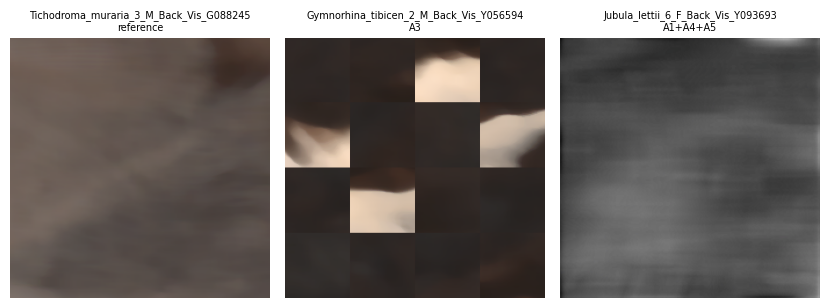

In [3]:
DISPLAY_CROP_INDEX = 8  # first native-224 crop (n_crops_per_size=8 -> 8x128 then 8x224, see chain.CROP_SIZES)


def show_batch(batch, crop_index=DISPLAY_CROP_INDEX):
    n = len(batch["stem"])
    fig, axes = plt.subplots(1, n, figsize=(2.8 * n, 3.2))
    if n == 1:
        axes = [axes]
    for ax, crops, stem, condition in zip(axes, batch["crops"], batch["stem"], batch["condition"]):
        img = crops[crop_index].permute(1, 2, 0).numpy()
        img = np.clip(img * IMAGENET_STD + IMAGENET_MEAN, 0.0, 1.0)
        ax.imshow(img)
        ax.set_title(f"{stem}\n{condition}", fontsize=7)
        ax.axis("off")
    fig.tight_layout()
    plt.show()


show_batch(batch)


## Chronometrer plusieurs sacs de suite

Meme mecanique que la cellule de tirage ci-dessus, repetee - les sacs qui
tombent sur A6 doivent nettement se detacher des autres dans les durees
affichees.

In [4]:
N_BATCHES = 5

for i in range(N_BATCHES):
    ts = datetime.now()
    t0 = time.perf_counter()
    fetched = None
    for attempt in range(1, MAX_ATTEMPTS + 1):
        try:
            fetched = next(iter(loader))
            break
        except (FileNotFoundError, TypeError):
            continue
    elapsed = time.perf_counter() - t0

    if fetched is None:
        print(f"[{ts.isoformat(timespec='seconds')}] batch {i}: failed ({MAX_ATTEMPTS} cache-miss draws in a row)")
        continue

    conditions = ", ".join(fetched["condition"])
    flag = "  <-- A6 (classification en ligne)" if any("A6" in c for c in fetched["condition"]) else ""
    print(f"[{ts.isoformat(timespec='seconds')}] batch {i}: {elapsed:5.2f}s   conditions: {conditions}{flag}")


[2026-09-15T11:13:21] batch 0: 17.15s   conditions: A1, A3, A4+A6  <-- A6 (classification en ligne)


[2026-09-15T11:13:38] batch 1:  2.81s   conditions: A5, A2, A4


[2026-09-15T11:13:41] batch 2: 29.28s   conditions: reference, A3, reference


[2026-09-15T11:14:10] batch 3: 13.98s   conditions: A4+A5+A6, reference, reference  <-- A6 (classification en ligne)


[2026-09-15T11:14:24] batch 4: 14.79s   conditions: A3+A5+A6, reference, reference  <-- A6 (classification en ligne)


## Timing par etape/ablation

`chain.build_bag()` chronometre maintenant chaque etape du pipeline
(protocole §2) et le renvoie dans `meta["timings"]` (secondes) : lecture
source (ou cache A1/A2/A7), A6 (l'etape en ligne la plus couteuse, categorie
tiree par sac), flip, flou median, A4, echantillonnage des positions,
extraction+resize des 16 crops, A3 et A5 (ces deux derniers sommes sur les
16 crops - ils sont tires par crop, pas par sac).

`BagDataset.__getitem__` (le chemin reellement utilise par le `DataLoader`
plus haut) jette `meta` - seuls `crops`/`habitat`/`support`/`stem`/`condition`
en ressortent, donc les timings ne sont pas visibles a travers le
`DataLoader`. La cellule ci-dessous appelle `chain.build_bag` directement,
avec exactement le meme calcul de rng que `BagDataset.__getitem__`
(`derive_rng(run_seed, epoch, index, stem)` puis `draw_condition(rng)`),
pour un sac tire au hasard, afin d'afficher le detail.

In [5]:
def build_one_with_timings(index):
    stem = dataset.stems[index]
    rng = derive_rng(dataset.run_seed, dataset.epoch, index, stem)
    condition = Condition() if dataset.sham else draw_condition(rng)
    return chain.build_bag(
        dataset.dataset_dir, dataset.dataset_a1_dir, dataset.dataset_a2_dir, dataset.dataset_a7_dir,
        stem, condition, rng,
    )


index_rng = np.random.default_rng()
meta_t = None
for attempt in range(1, MAX_ATTEMPTS + 1):
    index = int(index_rng.integers(len(dataset)))
    try:
        _crops_t, meta_t = build_one_with_timings(index)
        break
    except (FileNotFoundError, TypeError) as e:
        print(f"  [attempt {attempt}] {type(e).__name__}, redrawing another sac: {str(e).splitlines()[0]}")

if meta_t is None:
    raise RuntimeError(f"no valid sac found in {MAX_ATTEMPTS} draws")

def print_timings(meta):
    timings = meta["timings"]
    total = timings["total_s"]
    print(f"stem: {meta['stem']}   condition: {meta['condition']}\n")
    for name, seconds in sorted(timings.items(), key=lambda kv: -kv[1]):
        if name == "total_s":
            continue
        bar = "#" * max(1, round(seconds / total * 40))
        print(f"  {name:<22} {seconds:7.3f}s  ({seconds / total:5.1%})  {bar}")
    print(f"  {'total_s':<22} {total:7.3f}s  (100.0%)")


print_timings(meta_t)


stem: Monticola_explorator_5_F_Back_Vis_G127616   condition: reference

  median_blur_s            0.228s  (50.7%)  ####################
  read_source_s            0.135s  (30.1%)  ############
  sample_positions_s       0.085s  (18.8%)  ########
  crop_extract_resize_s    0.002s  ( 0.5%)  #
  flip_s                   0.000s  ( 0.0%)  #
  total_s                  0.451s  (100.0%)


Pour comparaison, l'exemple ci-dessus tombe sur une condition tiree au
hasard - elle peut ou non inclure A6. La cellule suivante force A6 (la seule
ablation encore calculee en ligne, protocole §3) sur le meme oiseau que le
tirage precedent, pour toujours voir son cout, meme quand le tirage
aleatoire ne l'a pas selectionne cette fois-ci.

In [6]:
forced_rng = derive_rng("notebook-timing-forced-A6", meta_t["stem"])
_crops_a6, meta_a6 = chain.build_bag(
    dataset.dataset_dir, dataset.dataset_a1_dir, dataset.dataset_a2_dir, dataset.dataset_a7_dir,
    meta_t["stem"], Condition(active=frozenset({"A6"})), forced_rng,
)
print_timings(meta_a6)


stem: Monticola_explorator_5_F_Back_Vis_G127616   condition: A6

  A6_s                    11.100s  (97.0%)  #######################################
  median_blur_s            0.224s  ( 2.0%)  #
  read_source_s            0.102s  ( 0.9%)  #
  sample_positions_s       0.010s  ( 0.1%)  #
  crop_extract_resize_s    0.002s  ( 0.0%)  #
  flip_s                   0.000s  ( 0.0%)  #
  total_s                 11.437s  (100.0%)


## Bug decouvert en route : `a5_spectral_slope.measure_alpha()` sur un crop uniforme

`apply()` (l'ablation A5 reellement executee par `chain.py`) appelle
`measure_alpha()` pour rapporter `alpha_after` dans les metadonnees. Quand
le crop tire est uniforme (typiquement un crop qui tombe entierement sur le
fond noir), son spectre radial (canal G) est nul a tous les rayons > 0, donc
la bande [2, 9] cycles/crop ne contient aucun point avec `profile > 0` -
`np.polyfit` recoit un vecteur vide et leve `TypeError: expected non-empty
vector for x`.

Reproduction minimale :

```python
from src.ablations import a5_spectral_slope as a5
import numpy as np
a5.measure_alpha(np.zeros((224, 224, 3), dtype=np.uint8))  # -> TypeError
```

C'est independant des caches A2/A7 : ca peut survenir sur n'importe quel
sac qui tire A5 (~24.6% de probabilite marginale, protocole §4), et ferait
planter un vrai entrainement (`src/training/run.py`) le jour ou un crop
tombe entierement sur le fond. Pas corrige ici - ce notebook le contourne
par retirage, comme pour les caches manquants, mais un vrai correctif
(par ex. `measure_alpha` retournant `None`/`nan` au lieu de lever, ou
`apply()` sautant le calcul de `alpha_after` quand la bande est vide)
merite d'etre fait dans `src/ablations/a5_spectral_slope.py`.